# New Section

In [66]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
os.makedirs("outputs/figures", exist_ok=True)

In [8]:
customer=pd.read_csv('QVI_purchase_behaviour.csv')
transactions=pd.read_excel('QVI_transaction_data.xlsx')

In [9]:
customer.head()

,LYLTY_CARD_NBR,LIFESTAGE,PREMIUM_CUSTOMER
0,1000,YOUNG SINGLES/COUPLES,Premium
1,1002,YOUNG SINGLES/COUPLES,Mainstream
2,1003,YOUNG FAMILIES,Budget
3,1004,OLDER SINGLES/COUPLES,Mainstream
4,1005,MIDAGE SINGLES/COUPLES,Mainstream


In [10]:
transactions.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9
3,2018-08-17,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0
4,2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8


In [11]:
transactions.columns


Index(['DATE', 'STORE_NBR', 'LYLTY_CARD_NBR', 'TXN_ID', 'PROD_NBR',
       'PROD_NAME', 'PROD_QTY', 'TOT_SALES'],
      dtype='str')

In [12]:
customer.columns

Index(['LYLTY_CARD_NBR', 'LIFESTAGE', 'PREMIUM_CUSTOMER'], dtype='str')

In [13]:
transactions.shape
transactions.info()

<class 'pandas.DataFrame'>
RangeIndex: 264836 entries, 0 to 264835
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   DATE            264836 non-null  datetime64[us]
 1   STORE_NBR       264836 non-null  int64         
 2   LYLTY_CARD_NBR  264836 non-null  int64         
 3   TXN_ID          264836 non-null  int64         
 4   PROD_NBR        264836 non-null  int64         
 5   PROD_NAME       264836 non-null  str           
 6   PROD_QTY        264836 non-null  int64         
 7   TOT_SALES       264836 non-null  float64       
dtypes: datetime64[us](1), float64(1), int64(5), str(1)
memory usage: 16.2 MB


In [14]:
customer.info()

<class 'pandas.DataFrame'>
RangeIndex: 72637 entries, 0 to 72636
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   LYLTY_CARD_NBR    72637 non-null  int64
 1   LIFESTAGE         72637 non-null  str  
 2   PREMIUM_CUSTOMER  72637 non-null  str  
dtypes: int64(1), str(2)
memory usage: 1.7 MB


In [15]:
transactions.isnull().sum()
transactions.isna().sum()


DATE              0
STORE_NBR         0
LYLTY_CARD_NBR    0
TXN_ID            0
PROD_NBR          0
PROD_NAME         0
PROD_QTY          0
TOT_SALES         0
dtype: int64

In [16]:
customer.isnull().sum()

customer.isna().sum()

LYLTY_CARD_NBR      0
LIFESTAGE           0
PREMIUM_CUSTOMER    0
dtype: int64

In [17]:
# transactions['DATE']=pd.to_datetime(transactions['DATE'],origin='1899-12-30',unit='D')

In [18]:
transactions.duplicated().sum()
#transactions.drop_duplicates(inplace=True)

np.int64(1)

In [19]:
transactions['PROD_QTY'].value_counts().sort_index()

PROD_QTY
1       27518
2      236039
3         430
4         397
5         450
200         2
Name: count, dtype: int64

In [20]:
transactions[transactions['PROD_QTY']<1]

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES


In [21]:
# transactions.drop(transactions[transactions['PROD_QTY']<1].index,inplace=True)

In [22]:
transactions['TOT_SALES'].describe()

count    264836.000000
mean          7.304200
std           3.083226
min           1.500000
25%           5.400000
50%           7.400000
75%           9.200000
max         650.000000
Name: TOT_SALES, dtype: float64

In [23]:
customer.isna().sum()

LYLTY_CARD_NBR      0
LIFESTAGE           0
PREMIUM_CUSTOMER    0
dtype: int64

In [24]:
customer.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
72632    False
72633    False
72634    False
72635    False
72636    False
Length: 72637, dtype: bool

In [25]:
customer


,LYLTY_CARD_NBR,LIFESTAGE,PREMIUM_CUSTOMER
0,1000,YOUNG SINGLES/COUPLES,Premium
1,1002,YOUNG SINGLES/COUPLES,Mainstream
2,1003,YOUNG FAMILIES,Budget
3,1004,OLDER SINGLES/COUPLES,Mainstream
4,1005,MIDAGE SINGLES/COUPLES,Mainstream
...,...,...,...
72632,2370651,MIDAGE SINGLES/COUPLES,Mainstream
72633,2370701,YOUNG FAMILIES,Mainstream
72634,2370751,YOUNG FAMILIES,Premium
72635,2370961,OLDER FAMILIES,Budget


In [26]:
customer['LYLTY_CARD_NBR'].duplicated().sum()

np.int64(0)

In [27]:
customer['PREMIUM_CUSTOMER'].unique()

<StringArray>
['Premium', 'Mainstream', 'Budget']
Length: 3, dtype: str

In [28]:
customer.groupby('PREMIUM_CUSTOMER')

In [29]:
customer['PREMIUM_CUSTOMER'].value_counts()

PREMIUM_CUSTOMER
Mainstream    29245
Budget        24470
Premium       18922
Name: count, dtype: int64

In [30]:
customer['LIFESTAGE'].value_counts()

LIFESTAGE
RETIREES                  14805
OLDER SINGLES/COUPLES     14609
YOUNG SINGLES/COUPLES     14441
OLDER FAMILIES             9780
YOUNG FAMILIES             9178
MIDAGE SINGLES/COUPLES     7275
NEW FAMILIES               2549
Name: count, dtype: int64

In [34]:
customer.to_csv('cleaned customer.csv',index=False)
transactions.to_excel('cleaned transactions.xlsx',index=False)

In [35]:
customers=pd.read_csv('cleaned customer.csv')
transactions=pd.read_excel('cleaned transactions.xlsx')

In [36]:
customers

,LYLTY_CARD_NBR,LIFESTAGE,PREMIUM_CUSTOMER
0,1000,YOUNG SINGLES/COUPLES,Premium
1,1002,YOUNG SINGLES/COUPLES,Mainstream
2,1003,YOUNG FAMILIES,Budget
3,1004,OLDER SINGLES/COUPLES,Mainstream
4,1005,MIDAGE SINGLES/COUPLES,Mainstream
...,...,...,...
72632,2370651,MIDAGE SINGLES/COUPLES,Mainstream
72633,2370701,YOUNG FAMILIES,Mainstream
72634,2370751,YOUNG FAMILIES,Premium
72635,2370961,OLDER FAMILIES,Budget


In [37]:
transactions

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9
3,2018-08-17,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0
4,2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8
...,...,...,...,...,...,...,...,...
264831,2019-03-09,272,272319,270088,89,Kettle Sweet Chilli And Sour Cream 175g,2,10.8
264832,2018-08-13,272,272358,270154,74,Tostitos Splash Of Lime 175g,1,4.4
264833,2018-11-06,272,272379,270187,51,Doritos Mexicana 170g,2,8.8
264834,2018-12-27,272,272379,270188,42,Doritos Corn Chip Mexican Jalapeno 150g,2,7.8


In [38]:
data=transactions.merge(customers,on='LYLTY_CARD_NBR',how='left')

In [39]:
data

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,LIFESTAGE,PREMIUM_CUSTOMER
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0,YOUNG SINGLES/COUPLES,Premium
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3,MIDAGE SINGLES/COUPLES,Budget
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9,MIDAGE SINGLES/COUPLES,Budget
3,2018-08-17,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0,MIDAGE SINGLES/COUPLES,Budget
4,2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8,MIDAGE SINGLES/COUPLES,Budget
...,...,...,...,...,...,...,...,...,...,...
264831,2019-03-09,272,272319,270088,89,Kettle Sweet Chilli And Sour Cream 175g,2,10.8,YOUNG SINGLES/COUPLES,Premium
264832,2018-08-13,272,272358,270154,74,Tostitos Splash Of Lime 175g,1,4.4,YOUNG SINGLES/COUPLES,Premium
264833,2018-11-06,272,272379,270187,51,Doritos Mexicana 170g,2,8.8,YOUNG SINGLES/COUPLES,Premium
264834,2018-12-27,272,272379,270188,42,Doritos Corn Chip Mexican Jalapeno 150g,2,7.8,YOUNG SINGLES/COUPLES,Premium


In [40]:
data.shape

(264836, 10)

In [41]:
data.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,LIFESTAGE,PREMIUM_CUSTOMER
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0,YOUNG SINGLES/COUPLES,Premium
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3,MIDAGE SINGLES/COUPLES,Budget
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9,MIDAGE SINGLES/COUPLES,Budget
3,2018-08-17,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0,MIDAGE SINGLES/COUPLES,Budget
4,2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8,MIDAGE SINGLES/COUPLES,Budget


In [42]:
data.isnull().sum()

DATE                0
STORE_NBR           0
LYLTY_CARD_NBR      0
TXN_ID              0
PROD_NBR            0
PROD_NAME           0
PROD_QTY            0
TOT_SALES           0
LIFESTAGE           0
PREMIUM_CUSTOMER    0
dtype: int64

In [43]:
data.duplicated().sum()

np.int64(1)

In [44]:
data['BRAND']=data['PROD_NAME'].str.split().str[0]
data['BRAND']

0          Natural
1              CCs
2           Smiths
3           Smiths
4           Kettle
            ...   
264831      Kettle
264832    Tostitos
264833     Doritos
264834     Doritos
264835    Tostitos
Name: BRAND, Length: 264836, dtype: object

In [45]:
data['PACK_SIZE']=data['PROD_NAME'].str.extract(r'(\d+)').astype(float)
data['PACK_SIZE']

0         175.0
1         175.0
2         170.0
3         175.0
4         150.0
          ...  
264831    175.0
264832    175.0
264833    170.0
264834    150.0
264835    175.0
Name: PACK_SIZE, Length: 264836, dtype: float64

In [46]:
data['MONTH']=data['DATE'].dt.to_period('M').astype(str)
data['MONTH']

0         2018-10
1         2019-05
2         2019-05
3         2018-08
4         2018-08
           ...   
264831    2019-03
264832    2018-08
264833    2018-11
264834    2018-12
264835    2018-09
Name: MONTH, Length: 264836, dtype: str

In [47]:
data

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,LIFESTAGE,PREMIUM_CUSTOMER,BRAND,PACK_SIZE,MONTH
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0,YOUNG SINGLES/COUPLES,Premium,Natural,175.0,2018-10
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3,MIDAGE SINGLES/COUPLES,Budget,CCs,175.0,2019-05
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9,MIDAGE SINGLES/COUPLES,Budget,Smiths,170.0,2019-05
3,2018-08-17,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0,MIDAGE SINGLES/COUPLES,Budget,Smiths,175.0,2018-08
4,2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8,MIDAGE SINGLES/COUPLES,Budget,Kettle,150.0,2018-08
...,...,...,...,...,...,...,...,...,...,...,...,...,...
264831,2019-03-09,272,272319,270088,89,Kettle Sweet Chilli And Sour Cream 175g,2,10.8,YOUNG SINGLES/COUPLES,Premium,Kettle,175.0,2019-03
264832,2018-08-13,272,272358,270154,74,Tostitos Splash Of Lime 175g,1,4.4,YOUNG SINGLES/COUPLES,Premium,Tostitos,175.0,2018-08
264833,2018-11-06,272,272379,270187,51,Doritos Mexicana 170g,2,8.8,YOUNG SINGLES/COUPLES,Premium,Doritos,170.0,2018-11
264834,2018-12-27,272,272379,270188,42,Doritos Corn Chip Mexican Jalapeno 150g,2,7.8,YOUNG SINGLES/COUPLES,Premium,Doritos,150.0,2018-12


In [48]:
data.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,LIFESTAGE,PREMIUM_CUSTOMER,BRAND,PACK_SIZE,MONTH
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0,YOUNG SINGLES/COUPLES,Premium,Natural,175.0,2018-10
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3,MIDAGE SINGLES/COUPLES,Budget,CCs,175.0,2019-05
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9,MIDAGE SINGLES/COUPLES,Budget,Smiths,170.0,2019-05
3,2018-08-17,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0,MIDAGE SINGLES/COUPLES,Budget,Smiths,175.0,2018-08
4,2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8,MIDAGE SINGLES/COUPLES,Budget,Kettle,150.0,2018-08


In [49]:
data

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,LIFESTAGE,PREMIUM_CUSTOMER,BRAND,PACK_SIZE,MONTH
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0,YOUNG SINGLES/COUPLES,Premium,Natural,175.0,2018-10
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3,MIDAGE SINGLES/COUPLES,Budget,CCs,175.0,2019-05
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9,MIDAGE SINGLES/COUPLES,Budget,Smiths,170.0,2019-05
3,2018-08-17,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0,MIDAGE SINGLES/COUPLES,Budget,Smiths,175.0,2018-08
4,2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8,MIDAGE SINGLES/COUPLES,Budget,Kettle,150.0,2018-08
...,...,...,...,...,...,...,...,...,...,...,...,...,...
264831,2019-03-09,272,272319,270088,89,Kettle Sweet Chilli And Sour Cream 175g,2,10.8,YOUNG SINGLES/COUPLES,Premium,Kettle,175.0,2019-03
264832,2018-08-13,272,272358,270154,74,Tostitos Splash Of Lime 175g,1,4.4,YOUNG SINGLES/COUPLES,Premium,Tostitos,175.0,2018-08
264833,2018-11-06,272,272379,270187,51,Doritos Mexicana 170g,2,8.8,YOUNG SINGLES/COUPLES,Premium,Doritos,170.0,2018-11
264834,2018-12-27,272,272379,270188,42,Doritos Corn Chip Mexican Jalapeno 150g,2,7.8,YOUNG SINGLES/COUPLES,Premium,Doritos,150.0,2018-12


In [50]:
data[['TOT_SALES','PROD_QTY']].describe()

,TOT_SALES,PROD_QTY
count,264836.000000,264836.000000
mean,7.304200,1.907309
std,3.083226,0.643654
min,1.500000,1.000000
25%,5.400000,2.000000
50%,7.400000,2.000000
75%,9.200000,2.000000
max,650.000000,200.000000


In [51]:
data['LIFESTAGE'].value_counts()

LIFESTAGE
OLDER SINGLES/COUPLES     54479
RETIREES                  49763
OLDER FAMILIES            48596
YOUNG FAMILIES            43592
YOUNG SINGLES/COUPLES     36377
MIDAGE SINGLES/COUPLES    25110
NEW FAMILIES               6919
Name: count, dtype: int64

In [52]:
data['PREMIUM_CUSTOMER'].value_counts()

PREMIUM_CUSTOMER
Mainstream    101988
Budget         93157
Premium        69691
Name: count, dtype: int64

In [53]:
Combo_sales = data.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER'])['TOT_SALES'].sum().reset_index().sort_values('TOT_SALES', ascending=False)
Combo_sales

,LIFESTAGE,PREMIUM_CUSTOMER,TOT_SALES
6,OLDER FAMILIES,Budget,168363.25
19,YOUNG SINGLES/COUPLES,Mainstream,157621.60
13,RETIREES,Mainstream,155677.05
15,YOUNG FAMILIES,Budget,139345.85
9,OLDER SINGLES/COUPLES,Budget,136769.80
10,OLDER SINGLES/COUPLES,Mainstream,133393.80
11,OLDER SINGLES/COUPLES,Premium,132263.15
12,RETIREES,Budget,113147.80
7,OLDER FAMILIES,Mainstream,103445.55
14,RETIREES,Premium,97646.05


In [54]:
Lifestage_sales = data.groupby(['LIFESTAGE'])['TOT_SALES'].sum().reset_index().sort_values('TOT_SALES', ascending=False)
Lifestage_sales

,LIFESTAGE,TOT_SALES
3,OLDER SINGLES/COUPLES,402426.75
4,RETIREES,366470.90
2,OLDER FAMILIES,353767.20
5,YOUNG FAMILIES,316160.10
6,YOUNG SINGLES/COUPLES,260405.30
0,MIDAGE SINGLES/COUPLES,184751.30
1,NEW FAMILIES,50433.45


In [55]:
Premium_sales= data.groupby(['PREMIUM_CUSTOMER'])['TOT_SALES'].sum().reset_index().sort_values('TOT_SALES', ascending=False)
Premium_sales

,PREMIUM_CUSTOMER,TOT_SALES
1,Mainstream,750744.50
0,Budget,676211.55
2,Premium,507458.95


In [56]:
customer_metrics = data.groupby('LYLTY_CARD_NBR').agg(
    total_spend=('TOT_SALES', 'sum'),
    total_qty=('PROD_QTY', 'sum'),
    transactions=('TXN_ID', 'nunique')
).reset_index()
customer_metrics

,LYLTY_CARD_NBR,total_spend,total_qty,transactions
0,1000,6.0,2,1
1,1002,2.7,1,1
2,1003,6.6,2,2
3,1004,1.9,1,1
4,1005,2.8,1,1
...,...,...,...,...
72632,2370651,13.0,2,1
72633,2370701,7.2,2,1
72634,2370751,9.2,2,1
72635,2370961,18.6,4,2


In [57]:
customer_metrics = customer_metrics.merge(customers, on='LYLTY_CARD_NBR', how='left')

In [58]:
segment_metrics = customer_metrics.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER']).agg(
    avg_spend=('total_spend', 'mean'),
    avg_qty=('total_qty', 'mean'),
    avg_transactions=('transactions', 'mean')
).reset_index().sort_values('avg_spend', ascending=False)

segment_metrics

,LIFESTAGE,PREMIUM_CUSTOMER,avg_spend,avg_qty,avg_transactions
7,OLDER FAMILIES,Mainstream,36.540286,9.804309,4.985164
8,OLDER FAMILIES,Premium,36.041513,9.749780,4.871592
6,OLDER FAMILIES,Budget,36.013529,9.639572,4.905882
15,YOUNG FAMILIES,Budget,34.689034,9.238486,4.722430
17,YOUNG FAMILIES,Premium,34.535758,9.209207,4.711878
16,YOUNG FAMILIES,Mainstream,34.013471,9.180352,4.695015
11,OLDER SINGLES/COUPLES,Premium,27.844874,7.154947,3.716632
9,OLDER SINGLES/COUPLES,Budget,27.747981,7.145466,3.712924
1,MIDAGE SINGLES/COUPLES,Mainstream,27.186781,6.796108,3.533234
10,OLDER SINGLES/COUPLES,Mainstream,27.057566,7.098783,3.690467


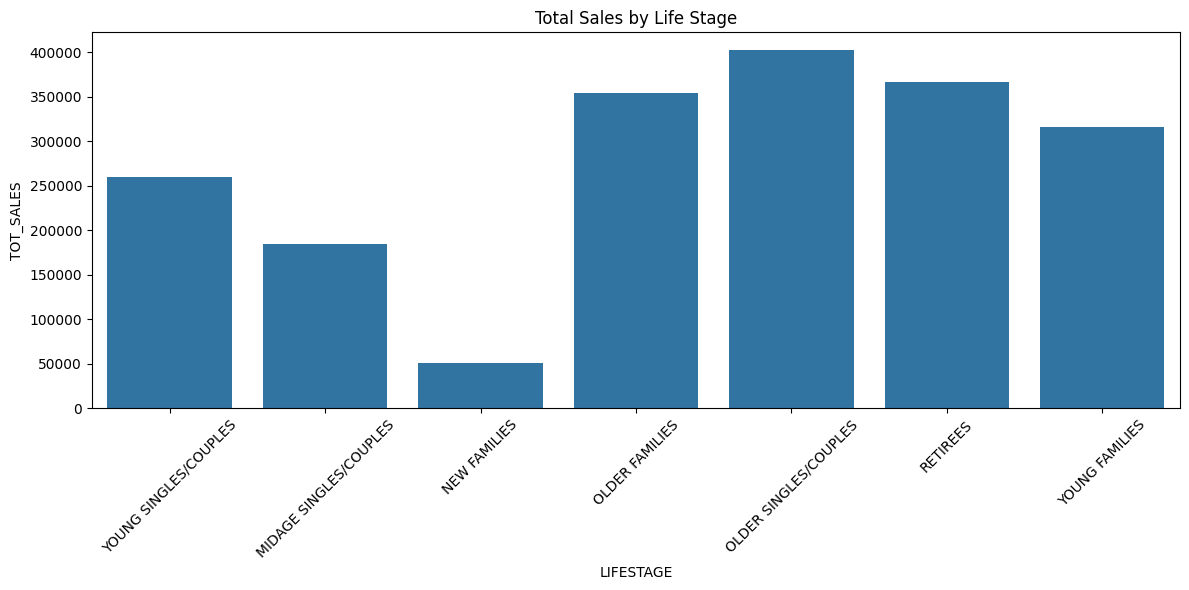

In [67]:
plt.figure(figsize=(12, 6))
sns.barplot(data=data, x='LIFESTAGE', y='TOT_SALES', estimator=sum, errorbar=None)
plt.xticks(rotation=45)
plt.title("Total Sales by Life Stage")
plt.tight_layout()
plt.savefig("outputs/figures/01_total_sales_by_lifestage.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

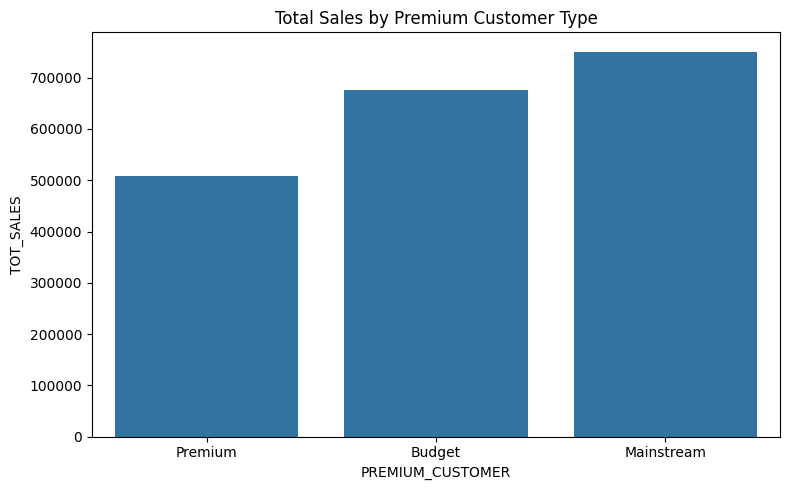

In [68]:
plt.figure(figsize=(8, 5))
sns.barplot(data=data, x='PREMIUM_CUSTOMER', y='TOT_SALES', estimator=sum, errorbar=None)
plt.title("Total Sales by Premium Customer Type")
plt.tight_layout()
plt.savefig("outputs/figures/02_total_sales_by_premium_customer.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

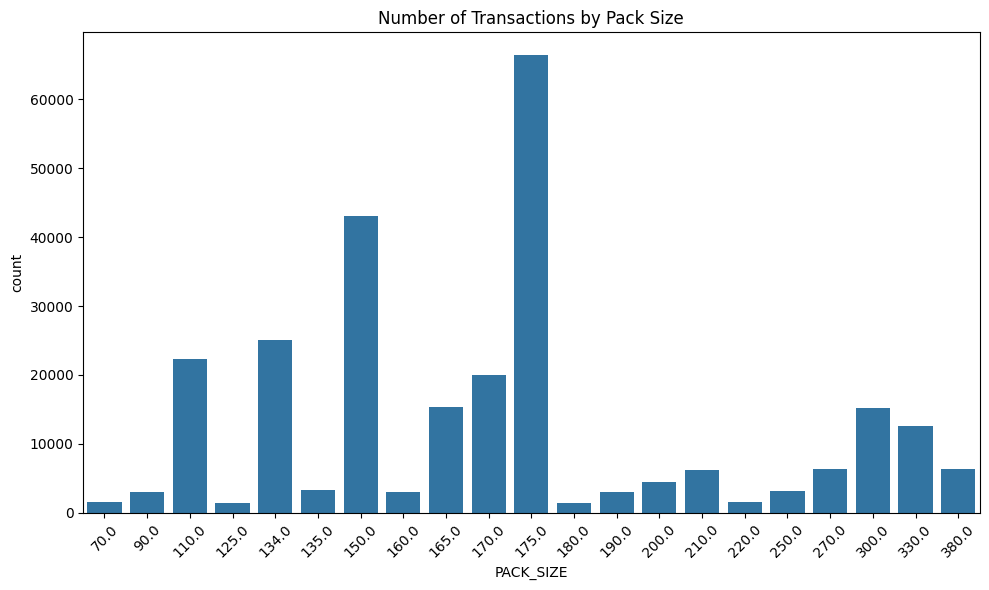

In [69]:
plt.figure(figsize=(10, 6))
sns.countplot(data=data, x='PACK_SIZE')
plt.xticks(rotation=45)
plt.title("Number of Transactions by Pack Size")
plt.tight_layout()
plt.savefig("outputs/figures/03_transactions_by_pack_size.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

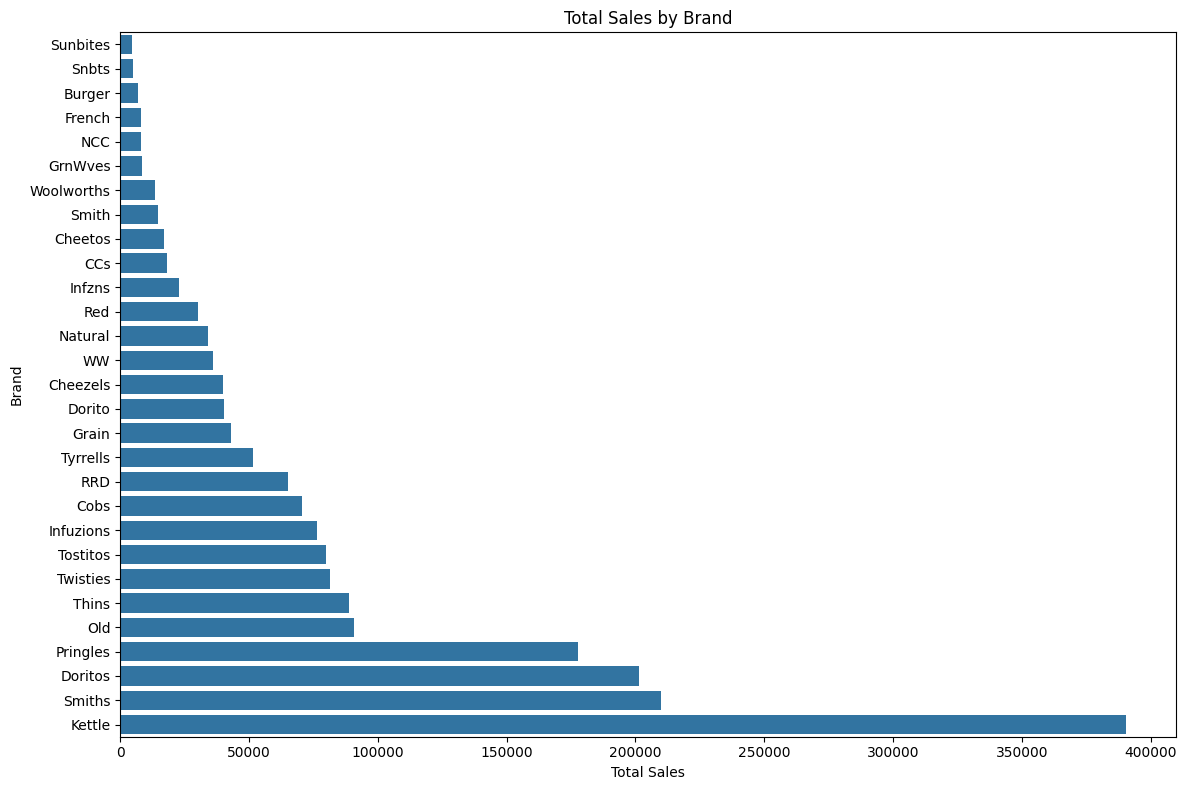

In [64]:
import os

# make output folder if it does not exist
os.makedirs("outputs/figures", exist_ok=True)

# aggregate brand sales first
brand_sales = (
    data.groupby("BRAND", as_index=False)["TOT_SALES"]
    .sum()
    .sort_values("TOT_SALES", ascending=True)
)

plt.figure(figsize=(12, 8))
sns.barplot(data=brand_sales, y="BRAND", x="TOT_SALES")

plt.title("Total Sales by Brand")
plt.xlabel("Total Sales")
plt.ylabel("Brand")
plt.tight_layout()

plt.savefig("outputs/figures/total_sales_by_brand.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

In [63]:
data.to_csv("cleaned_merged_data.csv", index=False)